In [34]:
import numpy as np
import pandas as pd
import os
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")




We know that most of the survivors were women, let's check the percentage of the women and the men who survived, respectively, then the ratio of women over men before and after the sinking

In [19]:
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)

print("% of women who survived:", rate_women)

% of women who survived: 0.7420382165605095


In [20]:
train_data.columns
men = train_data.loc[train_data.Sex == 'male']["Survived"]
rate_men = sum(men)/len(men)

print("% of women who survived:", rate_men)

% of women who survived: 0.18890814558058924


In [37]:
train_data.loc[train_data.Sex=="female"].count()
train_data.Sex.value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [38]:
train_data.groupby("Sex")["Survived"].agg(["sum", "count"])

,sum,count
Sex,,
female,233,314
male,109,577


la percentuale di donne sopravvissute è molto maggiore di quella per gli uomini tuttavia dato che il rapporto è sbilanciato  classificatore "naif" non è applicabile:
True Positives 233
False Positives: 81
False negatives: 109
con questo predittore avremmo una precisione di  circa 0.742 e il recall è circa 0.681

In [ ]:
#analisi esplorativa dei dati
#vediamo se e dove mancano dei dati. Si vede che la colonna Age e Cabin ha i dati mancanti e la colonna Cabin e Ticket sono superflue quindi le elimineremo 
#per rimuovere del rumore inutile
train_data.count()

PassengerId    891
Survived       891
Pclass         891
Name           891
Sex            891
Age            714
SibSp          891
Parch          891
Ticket         891
Fare           891
Cabin          204
Embarked       889
dtype: int64

In [ ]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:

train_data['Title'] = train_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Standardize titles
title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
train_data['Title'] = train_data['Title'].replace(title_mapping)
mask=~train_data['Title'].isin(["Mr", "Miss", "Mrs", 'Master'])
train_data.loc[mask,"Title"]=train_data.loc[mask,"Sex"].map({'male': 'Mr', 'female': 'Mrs'})
avg_age_per_title=train_data.groupby("Title")["Age"].mean()


Title
Master     4.574167
Miss      21.845638
Mr        32.984412
Mrs       35.991071
Name: Age, dtype: float64

<Axes: >

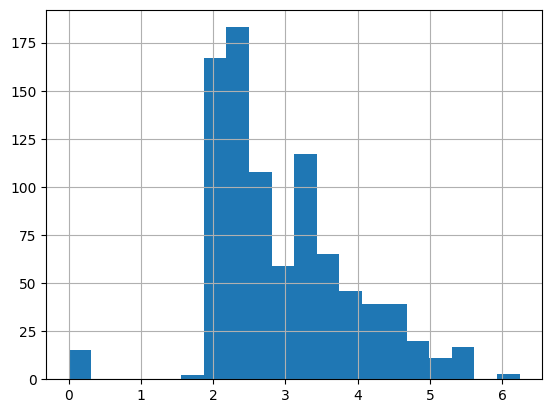

In [31]:
import math
train_data['Fare'] = train_data['Fare'].fillna(train_data['Fare'].median())
train_data['Fare'] 
train_data['Fare_log'] = np.log1p(train_data['Fare'])
train_data["Fare_log"].hist(bins=20)

In [ ]:
import pandas as pd
import numpy as np



def preprocess_df(df):
    """
    Processes data for Titanic Kaggle Competition.
    
    Args:
        df: Input DataFrame from train.csv or test.csv
     
        
    Returns:
        X (features) and y (target) DataFrames

    """
    df = df.copy()
    df = df.set_index('PassengerId')
    
    # Extract titles
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

    # Standardize titles
    title_mapping = {'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
    df['Title'] = df['Title'].replace(title_mapping)

    # Create mask for title replacement
    title_mask = ~df['Title'].isin(['Mr', 'Miss', 'Mrs', 'Master'])
    df.loc[title_mask, 'Title'] = df.loc[title_mask, 'Sex'].map({'male': 'Mr', 'female': 'Mrs'})
    
    # Medians for main titles collected previously manually
    title_age_medians = {
        'Mr': 32.984412,
        'Miss': 21.845638,
        'Mrs': 35.991071,
        'Master': 4.57
    }
    
    # Fill age based on title medians
    for title, median_age in title_age_medians.items():
        age_mask = (df['Age'].isnull()) & (df['Title'] == title)
        df.loc[age_mask, 'Age'] = median_age

    # Replace inplace fillna operations
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    df['Age*Class'] = df['Age'] * df['Pclass']
    df['Age*Fare'] = df['Age'] * df['Fare']    

    df_sex = pd.get_dummies(df['Sex'], prefix='sex', drop_first=True, dtype=int)
    df_Pclass = pd.get_dummies(df['Pclass'], prefix='class', drop_first=True, dtype=int)
    df_Embarked = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True, dtype=int)
    df_Title = pd.get_dummies(df['Title'], prefix='Title', drop_first=False, dtype=int)

    df = pd.concat([df, df_sex, df_Pclass, df_Embarked, df_Title], axis=1)

    # Family features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Fare and Age bands
    df['AgeBand'] = pd.cut(df['Age'], bins=[0, 12, 20, 40, 60, np.inf], labels=[0, 1, 2, 3, 4])
    df['AgeBand'] = df['AgeBand'].astype(int)
  
    # df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=[0, 1, 2, 3])
    # df['FareBand'] = df['FareBand'].astype(int)
    
    # Log transformation
    df['Fare_log'] = np.log1p(df['Fare'])

    df = df.drop(['Sex','Pclass','Name','Ticket','Embarked','Cabin', 'Title','Fare', 'SibSp', 'Parch'], axis=1)

    # Scaling - only scale numeric columns
    numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
    
    mew = df[numeric_columns].mean(axis=0)
    std = df[numeric_columns].std(axis=0)
    df[numeric_columns] = (df[numeric_columns] - mew) / std

    return df

In [7]:
from sklearn.ensemble import RandomForestClassifier
X=preprocess_df(train_data)
y = train_data["Survived"]
X=X.drop("Survived", axis=1)
X_test=preprocess_df(test_data)

In [8]:
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=2)
model.fit(X, y)
predictions = model.predict(X_test)
output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
